# Agentic RAG

Agentic RAG (Retrieval augmented generation) is a framework which enhances traditional RAG systems by incorporating **intelligent agents** to handle complex tasks and make decisions dynamically.

Use an agent to figure out how to retrieve the most relevant information before using the retrieved information to answer the user's question.

**Retrieval agents** are useful when we want to make decisions what to retrieve from an index (**Vector DB**).

To implement a **Retrieval Agent**, we need to give the LLM access to a **retrieval tool**.

In [1]:
import os
from dotenv import load_dotenv

env_path = '.env'
assert os.path.exists(env_path)

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

TAVILY_API_KEY = os.environ['TAVILY_API_KEY']
assert TAVILY_API_KEY
print(f'TAVILY_API_KEY: {TAVILY_API_KEY[:3]}**{TAVILY_API_KEY[-3:]}')

## Langsmith for debuging and tracing
LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}**{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
LANGCHAIN_TRACING_V2= os.environ['LANGCHAIN_TRACING_V2']
print(f'LANGCHAIN_TRACING_V2: {LANGCHAIN_TRACING_V2}')

LANGCHAIN_PROJECT = os.environ['LANGCHAIN_PROJECT']
print(f'LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA
TAVILY_API_KEY: tvl**66J
LANGCHAIN_API_KEY: lsv**43b
LANGCHAIN_TRACING_V2: false
LANGCHAIN_PROJECT: Agentic RAG tutorial


In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter

USER_AGENT environment variable not set, consider setting it to identify your requests.


### Read documents

1. Read documents from given URL list
2. Split them into chunks 

In [3]:
from collections import defaultdict
from pprint import pprint
from typing import List
from langchain_core.documents import Document

urls = [
    'https://langchain-ai.github.io/langgraph/concepts/why-langgraph/',
    'https://langcain-hain-ai.github.io/langgraph/tutorials/workflows/',
    'https://langchai.github.io/langgraph/how-tos/graph-api/#map-reduce-and-the-send-api'
]

loader = WebBaseLoader(web_paths=urls)

counts = defaultdict(int)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

docs: List[Document] = []
for doc in loader.lazy_load():
    source = doc.metadata['source']
    split_docs = text_splitter.split_documents([doc])
    docs.extend(split_docs)

print(f'Total number of documents: {len(docs)}')
pprint(docs[0])

Total number of documents: 6
Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/concepts/why-langgraph/', 'title': 'Overview', 'description': 'Build reliable, stateful AI systems, without giving up control', 'language': 'en'}, page_content='Overview\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n          Skip to content\n        \n\n\n\n\n\n\n\n            \n            \nThese docs will be deprecated and removed with the release of LangGraph v1.0 in October 2025. Visit the v1.0 alpha docs\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            LangGraph\n          \n\n\n\n            \n              Overview\n            \n          \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n            Initializing search\n          \n\n\n\n\n\n\n\n\n\n\n\n\n    GitHub\n  \n\n\n\n\n\n\n\n\n\n\n          \n  \n  \n    \n  \n  Get started\n\n        \n\n\n\n          \n  \n  \n    \n  \n  Guides\n\n        \n\n\n\n          \n  \n  \n    \n  \n

### Create Verctor DB

We will use `FAISS` as Vector store. 

We will use `OpenAIEmbeddings` to embed documents into vectors.

In [4]:
embeddings = OllamaEmbeddings(model='gemma:2b')
vector_store = FAISS.from_documents(documents=docs, embedding=embeddings)

retriever = vector_store.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x10e26ecf0>, search_kwargs={})

In [5]:
test_retr = retriever.invoke('What is Langgraph?')
test_retr

[Document(id='b2510288-4497-4233-b5a2-3196fc5b2284', metadata={'source': 'https://langchain-ai.github.io/langgraph/concepts/why-langgraph/', 'title': 'Overview', 'description': 'Build reliable, stateful AI systems, without giving up control', 'language': 'en'}, page_content='Table of contents\n    \n\n\n\n\n      Learn LangGraph basics\n    \n\n\n\n\n\n\n\n\n\n\n\n\n\n\nOverview¶\nLangGraph is built for developers who want to build powerful, adaptable AI agents. Developers choose LangGraph for:\n\nReliability and controllability. Steer agent actions with moderation checks and human-in-the-loop approvals. LangGraph persists context for long-running workflows, keeping your agents on course.\nLow-level and extensible. Build custom agents with fully descriptive, low-level primitives free from rigid abstractions that limit customization. Design scalable multi-agent systems, with each agent serving a specific role tailored to your use case.\nFirst-class streaming support. With token-by-token

#### Convert the Retriever to Retrieval tools

This will make our Retriever a tool, which can be integrated with LLMs.

In [6]:
from langchain.tools.retriever import create_retriever_tool

retrieval_tool = create_retriever_tool(retriever, 'retriever_vector_db_blog',
                                       'Search and run information about Langgraph')
retrieval_tool

Tool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x10e31e8e0>, retriever=VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x10e26ecf0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x10e344180>, retriever=VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x10e26ecf0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', r

### Vector database for Langchain

For Langchain Blogs we will create a separate Vector DB

In [7]:
langchain_urls = [
    'https://python.langchain.com/docs/tutorials/',
    'https://python.langchain.com/docs/tutorials/chatbot/',
    'https://python.langchain.com/docs/tutorials/qa_chat_history/'
]

web_loader_lc = WebBaseLoader(web_paths=langchain_urls)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=10)

docs: List[Document] = []
for doc in web_loader_lc.lazy_load():
    source = doc.metadata['source']
    split_docs = text_splitter.split_documents([doc])
    docs.extend(split_docs[:5])

print(f'Total number of documents: {len(docs)}')
pprint(docs[0])

Total number of documents: 15
Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'Tutorials | 🦜️🔗 LangChain', 'description': 'New to LangChain or LLM app development in general? Read this material to quickly get up and running building your first applications.', 'language': 'en'}, page_content='Tutorials | 🦜️🔗 LangChain')


In [8]:
embeddings_lc = OllamaEmbeddings(model='gemma:2b')

vector_store_lc = FAISS.from_documents(documents=docs, embedding=embeddings)

retriever_lc = vector_store_lc.as_retriever()
retrieval_tool_lc = create_retriever_tool(retriever, 'retriever_vector_langchain_blog',
                                          'Search and run information about Langchain')
retrieval_tool_lc

Tool(name='retriever_vector_langchain_blog', description='Search and run information about Langchain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x10e31e8e0>, retriever=VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x10e26ecf0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x10e344180>, retriever=VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x10e26ecf0>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\

In [9]:
tools = [retrieval_tool, retrieval_tool_lc]

### Langgraph Workflow

#### Create LLM for the Agent

In [10]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='qwen/qwen3-32b')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10e82b0e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10e82b8c0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [11]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages, BaseMessage

class AgentSate(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace, with add_messages it will append
    messages: Annotated[Sequence[BaseMessage], add_messages]

#### Graph strucuture

In [21]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain import hub 

# Nodes
def agent(state: AgentSate) -> AgentSate:
    """Invokes the LLM to generate a response based on the current state.
    Given the question it will decide to retrieve using the retrieval tool, or simply end

    Args:
        state (AgentSate): current state

    Returns:
        AgentSate: The updated state with the LLM response
    """

    print('---Call Agent---')
    model = ChatGroq(model='qwen/qwen3-32b').bind_tools(tools=tools)
    messages = state['messages']

    return { 'messages': [model.invoke(input=messages)] }

def generate(state: AgentSate) -> AgentSate:
    """Generate answer to the question

    Args:
        state (AgentSate): The current state

    Returns:
        AgentSate: The updated state
    """
    print('---Call Generate---')
    messages = state['messages']
    question = messages[0].content
    doc = messages[-1].content

    # Prompt 
    # https://smith.langchain.com/hub/rlm/rag-prompt?organizationId=a9402f23-0cd4-4009-8f20-15b305f46b4f
    rag_prompt = hub.pull('rlm/rag-prompt')
    print(f'---Rag prompt: {rag_prompt}---')

    # Create the llm
    llm = ChatGroq(model='qwen/qwen3-32b')

    # Create the chain
    rag_chain = rag_prompt | llm | StrOutputParser()

    # Run
    generated = rag_chain.invoke(input={ 'context': doc, 'question': question })
    return { 'messages': [generated] }

def rewrite(state: AgentSate) -> AgentSate:
    """Transform the query to produce a better question.

    Args:
        state (AgentSate): The current state

    Returns:
        AgentSate: The updated state
    """
    print('---Transform Query---')
    messages = state['messages']
    question = messages[-1].content

    msg = [
        HumanMessage(f"""Look at the input and try to reason about the underlying semantic intent/meaning\n
                     Here is the original question: \n\n
                     {question}\n\n
                     Formulate improved question: """)
    ]

    # Create LLM
    model = ChatGroq(model='qwen/qwen3-32b')

    # Call the LLM 
    response = model.invoke(msg)
    return { 'messages': [response] }

# Edges
def grade_documents(state: AgentSate) -> Literal['generate', 'rewrite']:
    """Determines if the retrieved documents are relevant to the question.

    Args:
        state: The current state

    Returns:
        str: The decision if the documents are relavant or not
    """

    print('---Call Relevance---')

    class Grade(BaseModel):
        """Binary score for relevance check"""
        binary_score: str = Field(description="Relevance score: 'yes' or 'no'")

    # Call LLM
    model = ChatGroq(model='qwen/qwen3-32b').with_structured_output(Grade)

    promt = PromptTemplate(template="""You are grader assessing relevance of retrieved documents to a user question.\n
                           Here is the retrieved document:\n\n {context}\n\n
                           Here is the user question: {question}\n
                           If the document contains keyword(s) or semantic meaning related to the user question grade it as related.\n
                           Give a binary score: 'yes' or 'no' to indicate if the document is relevant to the question.
                           """, input_variables=['context', 'question'])
    
    # Chain 
    chain = promt | model

    last_message = state['messages'][-1]
    doc = last_message.content

    # The question is the first message 
    question = state['messages'][0]

    # Call the llm
    score: Grade = chain.invoke(input={'context': doc, 'question': question})

    binary_score = score.binary_score

    if binary_score == 'yes':
        print('---Decision: Document IS RELEVANT---')
        return 'generate'
    
    print('----Decision: Document IS NOT RELEVANT---')
    return 'rewrite'

### Create the state graph

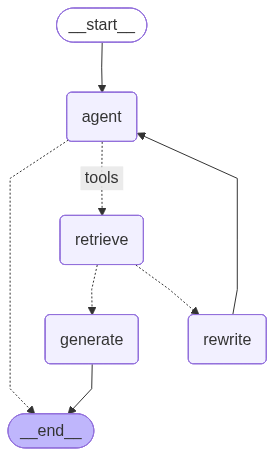

In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

from IPython.display import display, Image

graph_builder = StateGraph(AgentSate)

# Add nodes
graph_builder.add_node('agent', agent)
retrieve_node = ToolNode(tools=tools)
graph_builder.add_node('retrieve', retrieve_node)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('generate', generate)

# Add edges
graph_builder.add_edge(START, 'agent')
# Decide if it needs to retrieve 
graph_builder.add_conditional_edges('agent',
                                    # Assess agent decision
                                    tools_condition,
                                    {
                                        # Translate the condition outputs to nodes in the graph
                                        'tools': 'retrieve',
                                        END: END
                                    })
graph_builder.add_conditional_edges('retrieve', grade_documents, 
                                    {
                                        'generate': 'generate',
                                        'rewrite': 'rewrite'
                                    })
graph_builder.add_edge('generate', END)
graph_builder.add_edge('rewrite', 'agent')

# Compile the graph
graph = graph_builder.compile()

# Visualize 
display(Image(graph.get_graph().draw_mermaid_png()))


### Invoke the graph

In [24]:
input_state: AgentSate = {'messages': 'What is Langgraph?'}
output_state: AgentSate = graph.invoke(input=input_state)
output_state['messages']

---Call Agent---
---Call Relevance---
---Decision: Document IS RELEVANT---
---Call Generate---
---Rag prompt: input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]---


[HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='14e0c0a3-b637-4f0a-b2aa-a7b881438a15'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is Langgraph?" I need to figure out which function to use here. Let me check the available tools. There\'s a function called retriever_vector_db_blog that\'s for searching information about Langgraph. The other one is for Langchain. Since the question is about Langgraph, I should use the first function. The parameters require a query, so I\'ll use "What is Langgraph?" as the query string. I\'ll structure the tool call with the function name and the query argument.\n', 'tool_calls': [{'id': 'ghqhqn92a', 'function': {'arguments': '{"query":"What is Langgraph?"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 242, 'total_tokens': 382, 'completion_time': 0.226507333, 'prompt_t

In [25]:
input_state: AgentSate = {'messages': 'What is Langchain?'}
output_state: AgentSate = graph.invoke(input=input_state)
output_state['messages']

---Call Agent---
---Call Relevance---
----Decision: Document IS NOT RELEVANT---
---Transform Query---
---Call Agent---


[HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='3bd12513-7dd4-4518-91e2-7b0615e1220e'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is Langchain?" Let me figure out how to approach this.\n\nFirst, I need to recall what Langchain is. From what I remember, Langchain is a framework that helps in developing applications with large language models. It provides tools for integrating models with data sources, handling memory, and more. But I should verify this information.\n\nLooking at the available tools, there\'s a function called retriever_vector_langchain_blog. The description says it\'s for searching and running information about Langchain. That seems perfect for this query. I should use this tool to get accurate and up-to-date information.\n\nThe parameters required are a "query" string. The user\'s query is straightforward, so I can use "What is Langchain?" as the query argument. This shoul